# *Лабораторная работа №4*

## Построение регрессора для предсказания непрерывной величины (Теоретическая часть)

В данной лабораторной работе будет рассматриваться построение регрессионной модели для предсказания непрерывной величины. До текущего момента мы сталкивались только с задачей определения классовой принадлежности объекта, то есть в качестве результата должно было быть получено число из конечного множества целых чисел.

Подключим все необходимые библиотеки.

In [ ]:
import pandas as pd
from sklearn import ensemble
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Для примера построения регрессионной модели возьмем датасет, работу по очистке которого мы производили в рамках первой лабораторной (https://colab.research.google.com/drive/1fl7f7-8WA5GIjZ6qghfiD_2sEaCc1DQH?usp=sharing).

In [ ]:
%%capture
!wget https://www.dropbox.com/s/s1sqfsi6x7hbs28/autos_mod.csv

In [ ]:
df = pd.read_csv('autos_mod.csv', encoding='iso-8859-1')

In [ ]:
df.sample(10)

,Unnamed: 0,price,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage
37525,42482,8750,suv,2004,manuell,174,touareg,150000,diesel,volkswagen,NaN
272741,307238,6500,limousine,2007,manuell,95,one,90000,benzin,mini,NaN
184658,208114,1000,kleinwagen,2001,manuell,136,2_reihe,125000,benzin,peugeot,nein
88431,99781,14000,suv,2007,automatik,225,touareg,150000,diesel,volkswagen,NaN
323206,364261,2500,kombi,2006,manuell,109,focus,150000,diesel,ford,nein
52213,58983,3999,kombi,2003,automatik,131,passat,150000,diesel,volkswagen,nein
127387,143591,0,kleinwagen,2001,manuell,75,lupo,150000,benzin,volkswagen,nein
271022,305299,250,kleinwagen,1992,manuell,75,golf,150000,NaN,volkswagen,NaN
17107,19395,1490,kleinwagen,2003,manuell,82,clio,150000,diesel,renault,nein
319388,359916,350,NaN,2016,manuell,55,clio,150000,NaN,renault,nein


Удалим лишний столбец, возникший в результате записи датасета в файл. Кроме того, очистим базу от пустых значений, так как не все регрессионные методы могут обрабатывать поврежденные данные.

In [ ]:
del df['Unnamed: 0']
df_wo_na = df.dropna()
df_wo_na.reset_index(inplace=True)
del df_wo_na['index']

Проверим, что остались только необходимые нам столбцы.

In [ ]:
df_wo_na.sample(10)

,price,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage
78401,380,kleinwagen,2004,manuell,58,twingo,125000,benzin,renault,ja
116876,8999,limousine,2008,manuell,105,golf,80000,diesel,volkswagen,nein
247413,8890,suv,2004,manuell,174,touareg,150000,diesel,volkswagen,nein
128870,1950,bus,2000,manuell,70,berlingo,150000,benzin,citroen,nein
130021,1100,kombi,1999,automatik,116,vectra,150000,benzin,opel,nein
83048,2700,kombi,2006,manuell,120,vectra,150000,diesel,opel,nein
153936,0,limousine,2002,automatik,214,s_klasse,150000,diesel,mercedes_benz,ja
98853,4500,cabrio,2002,automatik,231,3er,125000,benzin,bmw,nein
155117,18500,limousine,2012,manuell,156,a_klasse,30000,benzin,mercedes_benz,nein
30581,6000,bus,2000,manuell,102,transporter,150000,diesel,volkswagen,nein


Проведем факторизацию в столбцах со строковыми значениями. Для этого выпишем имена всех объектных столбцов и в цикле будем вызывать factorize из библиотеки pandas. [0] в конце строки с командой необходим так как factorize возвращает два набора значений - преобразованный столбец значений и упорядоченный список меток. Так как проводить операцию обратную факторизации мы не собираемся, то и второй столбец для нас не представляет интереса.

In [ ]:
column_names = ['vehicleType', 'gearbox', 'model', 'fuelType', 'brand', 'notRepairedDamage']
for i in column_names:
  df_wo_na[i] = pd.factorize(df_wo_na[i])[0]

/tmp/ipython-input-3782041018.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wo_na[i] = pd.factorize(df_wo_na[i])[0]
/tmp/ipython-input-3782041018.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wo_na[i] = pd.factorize(df_wo_na[i])[0]
/tmp/ipython-input-3782041018.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

Разобьем выборку на тренировочный и тестовый наборы.

In [ ]:
Y = df_wo_na['price']
X = df_wo_na.drop(['price'], axis = 1)
train_points, test_points, train_values, test_values = train_test_split(X, Y, test_size = 0.2, random_state=42)

Обучим модель случайного леса из 100 решающих деревьев.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_points, train_values)

RandomForestRegressor(random_state=42)

Оценку эффективности нашей модели проведем через расчет MAE. MAE (Mean Absolute Error) - средняя абсолютная ошибка, рассчитанная как сумма абсолютных ошибок в каждом предсказании, деленная на общий размер выборки.

In [ ]:
rf_predict = rf_model.predict(test_points)
print(mean_absolute_error(test_values, rf_predict))

4642.013307472782


Разброс предсказнной цены больше $4000 не вызывает особого восторга. Попробуем произвести обучение модели, построенной на градиентном бустинге.

In [ ]:
import xgboost as xgb
xg_reg = xgb.XGBRegressor(objective = 'reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                max_depth = 5, alpha = 10, n_estimators = 100, random_state=42)

In [ ]:
xg_reg.fit(train_points, train_values)

XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, ...)

In [ ]:
xgb_predict = xg_reg.predict(test_points)

Оценим качество получившейся модели.

In [ ]:
print(mean_absolute_error(test_values, xgb_predict))

6702.5361328125


Градиентный бустинг показал результаты еще хуже, чем были до этого... Попробуем проанализировать причины такого поведения.

Выведем график соответствия предсказанной и фактической цены.

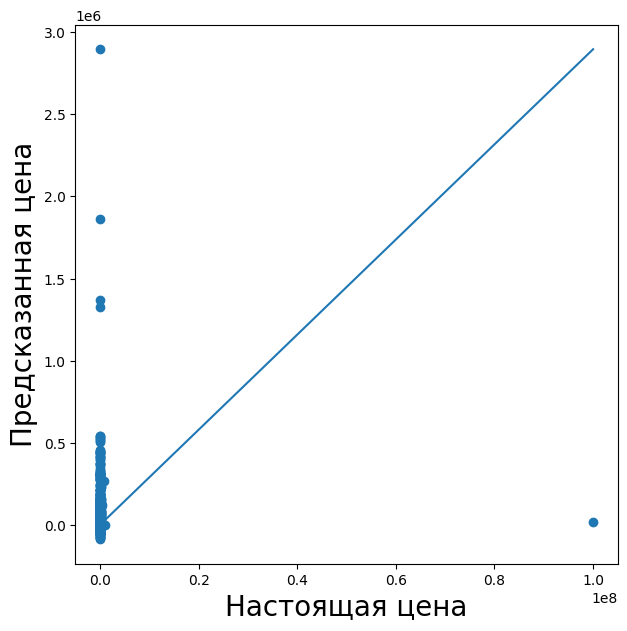

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(test_values, xgb_predict) # рисуем точки, соответствущие парам настоящее значение - прогноз
plt.plot([0, max(test_values)], [0, max(xgb_predict)]) # рисуем прямую, на которой предсказания и настоящие значения совпадают
plt.xlabel('Настоящая цена', fontsize=20)
plt.ylabel('Предсказанная цена', fontsize=20);

Благодаря графическому представлению мы обнаружили сильнейшие вылеты максимальной цены автомобилей. Произведем анализ данного столбца.

array([[<Axes: title={'center': 'price'}>]], dtype=object)

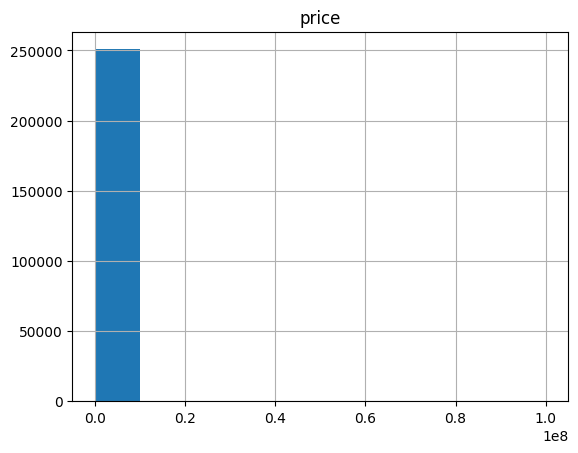

In [ ]:
df_wo_na.hist(["price"])

На гистограмме видно, что у нас есть экземпляры, цена на которые доходит до 100 миллиардов. Произведем отбор записей по цене, исключив также записи со слишком низкой ценой.

In [ ]:
df_wo_na = df_wo_na[(df_wo_na['price'] < 20000) & (df_wo_na['price'] > 50)]
df_wo_na.reset_index(inplace=True)
del df_wo_na['index']

Выведем гисторгамму для распределения цен на автомобили после внесенных нами изменений.

array([[<Axes: title={'center': 'price'}>]], dtype=object)

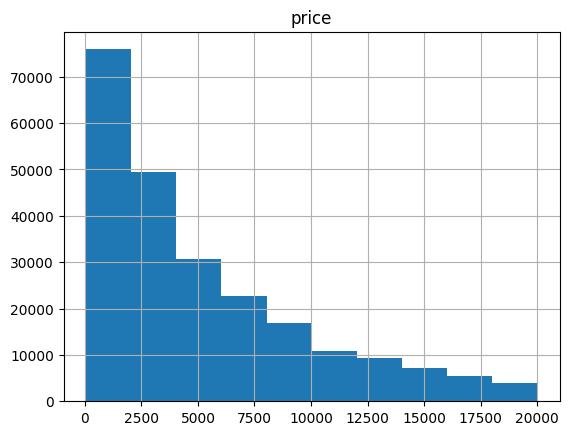

In [ ]:
df_wo_na.hist(["price"])

Вновь проведем разделение на тренировочную и тестовую выборки.

In [ ]:
Y = df_wo_na['price']
X = df_wo_na.drop(['price'], axis = 1)
train_points, test_points, train_values, test_values = train_test_split(X, Y, test_size = 0.2, random_state=42)

Создадим модель градиентного бустинга на основе обновленных данных.

In [ ]:
xg_reg.fit(train_points, train_values)

XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, ...)

In [ ]:
xgb_predict = xg_reg.predict(test_points)

In [ ]:
print(mean_absolute_error(test_values, xgb_predict))

1290.8162841796875


Получившийся результат гораздо лучше с точки зрения отклонения абсолютной ошибки. Выведем график, чтобы оценить произошедшие изменения.

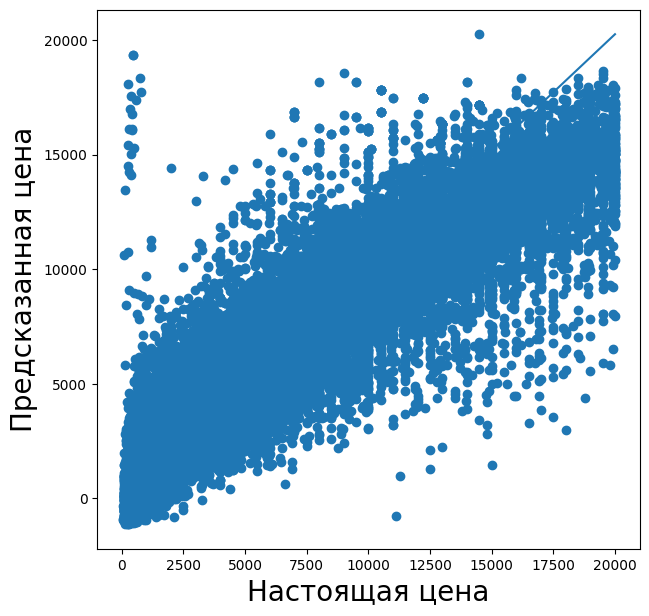

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(test_values, xgb_predict) # рисуем точки, соответствущие парам настоящее значение - прогноз
plt.plot([0, max(test_values)], [0, max(xgb_predict)]) # рисуем прямую, на которой предсказания и настоящие значения совпадают
plt.xlabel('Настоящая цена', fontsize=20)
plt.ylabel('Предсказанная цена', fontsize=20);

На графике явно видно, что наша модель показывает гораздо худшие резуьтаты для автомобилей с низкой стоимостью. Запомним этот факт и попробуем собрать модель на основе случайного леса, так как до проведения фильтрации по цене градиентный бустинг показывал худшие результаты.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_points, train_values)
rf_predict = rf_model.predict(test_points)

In [ ]:
print(mean_absolute_error(test_values, rf_predict))

979.0815117416805


Средняя абсолютная ошибка меньше для модели случайного леса почти на $300, что является серьезным аргументом в ее пользу. Выведем график с отклонениями.

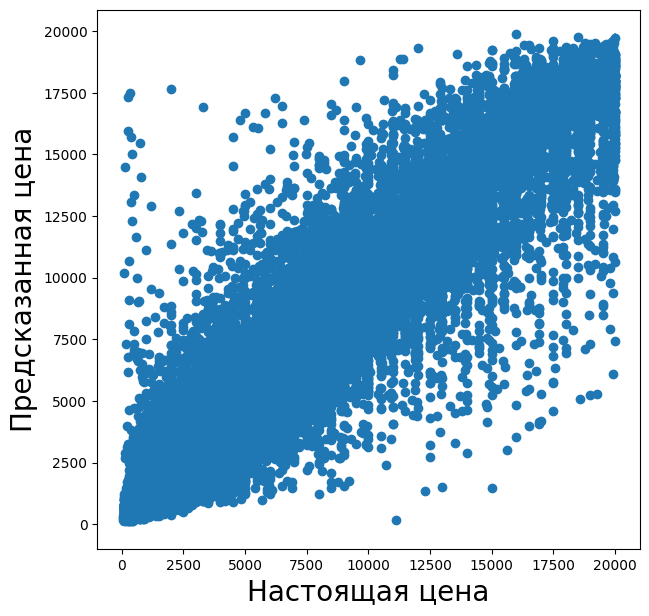

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(test_values, rf_predict) # рисуем точки, соответствущие парам настоящее значение - прогноз
plt.plot([0, max(test_values)], [0, max(rf_predict)]) # рисуем прямую, на которой предсказания и настоящие значения совпадают
plt.xlabel('Настоящая цена', fontsize=20)
plt.ylabel('Предсказанная цена', fontsize=20);

Теперь давайте разберемся в причинах того, что градиентный бустинг показывает результаты гораздо хуже случайного леса. Разгадка кроется в типах ансамблевых методов, которые лежат в основе данных моделей.

Случайный лес работает на основе бэггинга, то есть собирает ансамбль из слабых учеников, каждый из которых имеет собственный независимый набор данных и, как следствие, свой набор правил разделения записей. После получения решения от всех учеников принимается некое усредненное значение.

Градиентный бустинг же направлен на исправление результата самого слабого ученика. Это приводит к тому, что итоговая модель будет смещаться в направлении самых больших вылетов, что мы и видели на графиках выше.

Можно сделать вывод, что механизм градиентного бустинга наилучшим образом подходит для решения задач со взвешенным набором данных, т.е. с (примерно) равным количеством записей, относящихся к каждому классу, либо диапазону значений.

Ну и проверим, каким образом скажется на качестве моделей разделение столбцов по способу факторизации.

In [ ]:
df_wo_na = df.dropna()
df_wo_na.reset_index(inplace=True)
del df_wo_na['index']

Для столбцов с высокой кардинальностью оставим стандартный алгоритм, а для столбцов с низкой применим OneHotEncoding.

In [ ]:
column_names_fact = ['vehicleType', 'model','brand']
column_names_dummies = ['gearbox', 'fuelType', 'notRepairedDamage']
for i in column_names_fact:
  df_wo_na[i] = pd.factorize(df_wo_na[i])[0]
df_wo_na = pd.get_dummies(df_wo_na, prefix=column_names_dummies)

/tmp/ipython-input-3607016515.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wo_na[i] = pd.factorize(df_wo_na[i])[0]
/tmp/ipython-input-3607016515.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wo_na[i] = pd.factorize(df_wo_na[i])[0]
/tmp/ipython-input-3607016515.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [ ]:
df_wo_na = df_wo_na[(df_wo_na['price'] < 20000) & (df_wo_na['price'] > 50)]
df_wo_na.reset_index(inplace=True)
del df_wo_na['index']

In [ ]:
Y = df_wo_na['price']
X = df_wo_na.drop(['price'], axis = 1)

In [ ]:
train_points, test_points, train_values, test_values = train_test_split(X, Y, test_size = 0.2, random_state=42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(train_points, train_values)
rf_predict = rf_model.predict(test_points)

In [ ]:
print(mean_absolute_error(test_values, rf_predict))

978.2036634798429


Модель случайного леса осталась равнодушна к увеличению количества столбцов.

In [ ]:
xg_reg.fit(train_points, train_values)
xgb_predict = xg_reg.predict(test_points)
print(mean_absolute_error(test_values, xgb_predict))

1200.2088623046875


А вот градиентный бустинг значительно улучшил точность предсказываемой цены.

В заключение попробуем создать ансамбль из моделей, каждая из которых будет предсказывать цену только для автомобилей конкретной марки.

In [ ]:
df = pd.read_csv('autos_mod.csv', encoding='iso-8859-1')

In [ ]:
del df['Unnamed: 0']
df_wo_na = df.dropna()
df_wo_na = df_wo_na[(df_wo_na['price'] < 20000) & (df_wo_na['price'] > 50)]
df_wo_na.reset_index(inplace=True)
del df_wo_na['index']

Факторизацию проводим для всех столбцов, кроме марки автомобиля, так как по значению данного столбца в дальнейшем будет осуществляться разделение.

In [ ]:
column_names = ['vehicleType', 'gearbox', 'model', 'fuelType', 'notRepairedDamage']
for i in column_names:
  df_wo_na[i] = pd.factorize(df_wo_na[i])[0]

Выводим уникальные значения в столбце бренда.

In [ ]:
df_wo_na['brand'].unique()

array(['volkswagen', 'skoda', 'bmw', 'peugeot', 'mazda', 'nissan',
       'renault', 'ford', 'mercedes_benz', 'seat', 'honda', 'fiat',
       'mini', 'smart', 'audi', 'alfa_romeo', 'subaru', 'mitsubishi',
       'opel', 'hyundai', 'lancia', 'citroen', 'toyota', 'kia',
       'chevrolet', 'dacia', 'suzuki', 'daihatsu', 'chrysler', 'volvo',
       'jaguar', 'rover', 'porsche', 'jeep', 'saab', 'daewoo',
       'land_rover', 'trabant', 'lada'], dtype=object)

Разделяем датасет на тренировочную и тестовую части.

In [ ]:
train, test = train_test_split(df_wo_na, test_size=0.2, random_state=42)

Проверяем, что количество марок совпадает в тренировочном и тестовом наборе данных. Здесь используется небольшое допущение, что совпадения по количеству уникальных значений достаточно, но для релизной модели потребуется сравнение словарей в тренировочной и тестовой выборках.

In [ ]:
len(train['brand'].unique())

39

In [ ]:
len(test['brand'].unique())

39

Реализация дальнейшего маршрута обработки данных и создания модели специально дана в максимально читаемом виде для наглядности.

В первую очередь создаем словари из наборов данных. Тренировочный набор данных раделяем по признаку бренда таким образом, чтобы по ключу этого бренда был доступен набор данных содержащий исключительно записи с соответствующим брендом. Аналогично поступаем с тестовым набором данных.

In [ ]:
datasets_train = dict()
datasets_test = dict()

for i in train['brand'].unique() :
  datasets_train[i] = train[train['brand'] == i]

for i in test['brand'].unique() :
  datasets_test[i] = test[test['brand'] == i]

Затем необходимо каждый из имеющихся словарей разделить на входные и выходные данные (points и values). Кроме того, из входных данных следует удалить столбец 'brand', так как он не участвует в принятии решения моделью.

In [ ]:
datasets_train_points = dict()
datasets_train_values = dict()

datasets_test_points = dict()
datasets_test_values = dict()

for i in train['brand'].unique() :
  datasets_train_points[i] = datasets_train[i].drop(['price', 'brand'], axis = 1)
  datasets_train_values[i] = datasets_train[i]['price']

for i in test['brand'].unique() :
  datasets_test_points[i] = datasets_test[i].drop(['price', 'brand'], axis = 1)
  datasets_test_values[i] = datasets_test[i]['price']

Создаем словарь из моделей по 10 деревьев в каждой и массив для хранения результатов работы моделей. Затем в цикле обучаем каждую модель на выделенном ей фрагменте данных, тестируем ее и результаты тестирования записываем в массив резултатов.

In [ ]:
models = dict()
models_results = list()

for i in train['brand'].unique() :
  models[i] = RandomForestRegressor(n_estimators=10, random_state=42)
  models[i].fit(datasets_train_points[i], datasets_train_values[i])
  lr_predict = models[i].predict(datasets_test_points[i])
  print(i, mean_absolute_error(datasets_test_values[i], lr_predict))
  models_results.append([len(datasets_test_points[i]), mean_absolute_error(datasets_test_values[i], lr_predict)])

seat 744.1575220885425
toyota 912.4512701088947
opel 646.9840944400813
volkswagen 1009.9318394693039
nissan 885.117560052982
audi 1260.5260265796821
mazda 832.1965041259444
daihatsu 489.060009443429
skoda 990.4120683287135
land_rover 2012.0409378139443
smart 615.173600762497
mini 1133.4528250154715
subaru 1241.2510889110886
mercedes_benz 1341.6427483167856
bmw 1267.310184462311
fiat 674.0701743564002
rover 725.3907454648527
ford 759.0496666333778
renault 635.7567539193969
kia 896.4162768008155
citroen 860.7592098313183
daewoo 326.6076731601732
volvo 1119.0500957630543
peugeot 710.2757660242546
jeep 2268.785751305573
lancia 722.0919696969698
honda 776.8749675670567
mitsubishi 748.7003854309696
chrysler 1102.71109479323
chevrolet 1350.8932403581268
porsche 2404.227250793037
alfa_romeo 1154.3169031330256
suzuki 816.5024630542671
hyundai 811.1077409501897
lada 916.5568181818184
dacia 1173.335782492701
saab 1315.1598020772096
jaguar 2173.354573234984
trabant 1302.5405112044818


Анализировать полученные результаты довольно сложно, так как не ясна итоговая точность работы модели. Для ее определения и создавался вспомогательный массив из результатов измерений. В него мы записывали количество записей каждой марки и точность, полученную на этих данных.

Чтобы из этих данных получить итоговое значение метрики MAE необходимо умножить локальное значение метрики на количество записей, для которых происходило предсказание. Таким образом мы получим суммарную ошибку модели в рамках бренда. А сложив все ошибки моделей по брендам и разделив на общее число записей получим среднюю абсолютную ошибку для всего датасета.

In [ ]:
counter = 0
sum = 0
for i in range(len(models_results)):
  counter = counter + models_results[i][0]
  sum = sum + models_results[i][0] * models_results[i][1]

print(sum / counter)

989.210246405417


Точность получилась сопоставимой с базовой моделью случайного леса, а точнее чуть хуже, чем было в исходном варианте.

Проверим, что будет если увеличить количество деревьев в каждой локальной модели до 100.

In [ ]:
models = dict()
models_results = list()

for i in train['brand'].unique() :
  models[i] = RandomForestRegressor(n_estimators=100, random_state=42)
  models[i].fit(datasets_train_points[i], datasets_train_values[i])
  lr_predict = models[i].predict(datasets_test_points[i])
  print(i, mean_absolute_error(datasets_test_values[i], lr_predict))
  models_results.append([len(datasets_test_points[i]), mean_absolute_error(datasets_test_values[i], lr_predict)])

seat 734.9310530431245
toyota 881.5575199438531
opel 634.4292120303841
volkswagen 995.0471003276041
nissan 850.5551950255472
audi 1235.4493879025856
mazda 791.1481759948065
daihatsu 494.25742506423444
skoda 975.6918068765422
land_rover 2029.2224508227355
smart 607.6403079858114
mini 1107.0318070778471
subaru 1162.8916339123837
mercedes_benz 1309.0731886354517
bmw 1244.0146364929433
fiat 656.7262750276294
rover 655.0250274830601
ford 738.4948580590801
renault 617.5209052137781
kia 873.0601936991651
citroen 833.1313264819022
daewoo 319.0507870370371
volvo 1101.6455349477185
peugeot 688.419029801517
jeep 2147.594368062473
lancia 775.7973336416109
honda 768.9320816849992
mitsubishi 734.6729775819837
chrysler 1053.9056007417912
chevrolet 1288.560553993527
porsche 2266.112604534781
alfa_romeo 1117.951212098638
suzuki 805.7909001078426
hyundai 769.9167090103575
lada 859.7769480519484
dacia 1128.1991448726988
saab 1257.491157750343
jaguar 2189.5614676484092
trabant 1156.314739729225


In [ ]:
counter = 0
sum = 0
for i in range(len(models_results)):
  counter = counter + models_results[i][0]
  sum = sum + models_results[i][0] * models_results[i][1]

print(sum / counter)

967.5869029845454


Итоговая точность стала лучше, чем у базовой модели. Если ввести дополнительные критерии разделения, можно претендовать на еще большее улучшение.

## Построение регрессора для предсказания непрерывной величины (*Практическая* часть)

Вашим заданием в данной лабораторной будет построение ансамбля регрессионных моделей для предсказания цены квартиры для датасета (разделение сфер ответственности моделей не может осуществляться по целевому столбцу), содержащего информацию о продаже недвижимости в Нью-Йорке.

https://www.kaggle.com/new-york-city/nyc-property-sales

In [ ]:
%%capture
!wget https://www.dropbox.com/s/0un1sdvifenp2ir/nyc-rolling-sales.csv